In [41]:
import numpy as np
import matplotlib.pyplot as plt
import os
import gzip

In [42]:
def load_idx_gz(path):
    with gzip.open(path, "rb") as f:
        data = f.read()

    magic = int.from_bytes(data[0:4], "big")

    if magic == 2051:  # images
        n = int.from_bytes(data[4:8], "big")
        rows = int.from_bytes(data[8:12], "big")
        cols = int.from_bytes(data[12:16], "big")
        arr = np.frombuffer(data, dtype=np.uint8, offset=16)
        return arr.reshape(n, rows, cols)

    elif magic == 2049:  # labels
        n = int.from_bytes(data[4:8], "big")
        arr = np.frombuffer(data, dtype=np.uint8, offset=8)
        return arr

    else:
        raise ValueError("Unknown IDX format")

In [43]:
data_dir = "./fashion-mnist/data/fashion"

train_images = load_idx_gz(os.path.join(data_dir,"train-images-idx3-ubyte.gz"))
train_labels = load_idx_gz(os.path.join(data_dir,"train-labels-idx1-ubyte.gz"))
test_images  = load_idx_gz(os.path.join(data_dir,"t10k-images-idx3-ubyte.gz"))
test_labels  = load_idx_gz(os.path.join(data_dir,"t10k-labels-idx1-ubyte.gz"))

print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [44]:
X_train = train_images.reshape(len(train_images), -1) / 255.0
X_test  = test_images.reshape(len(test_images), -1) / 255.0

y_train = train_labels
y_test  = test_labels

print(X_train.shape, X_test.shape)

(60000, 784) (10000, 784)


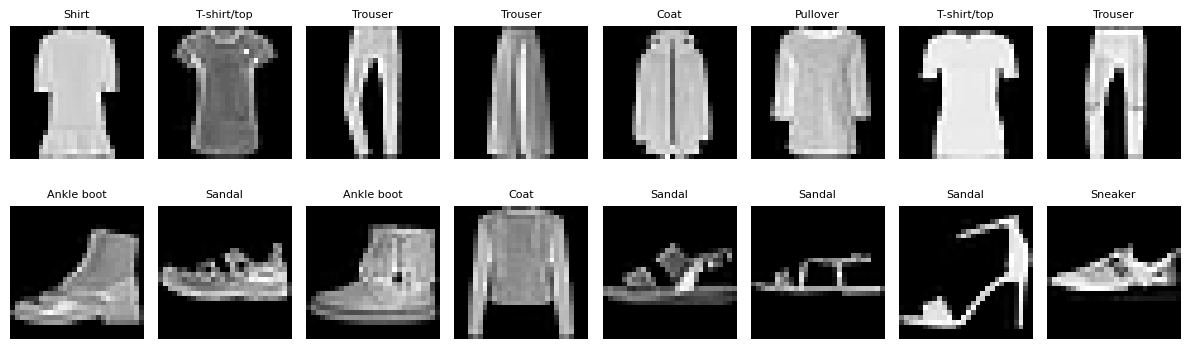

In [45]:
class_names = [
"T-shirt/top","Trouser","Pullover","Dress","Coat",
"Sandal","Shirt","Sneaker","Bag","Ankle boot"
]

fig, axes = plt.subplots(2,8,figsize=(12,4))

for ax in axes.ravel():
    idx = np.random.randint(len(train_images))
    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(class_names[train_labels[idx]], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [46]:
## SAMPLE

In [47]:
## TRAIN/VALIDATION

In [48]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train
)

print(X_tr.shape, X_val.shape)

(48000, 784) (12000, 784)


In [49]:
## CLASSIFIER 1: kNN

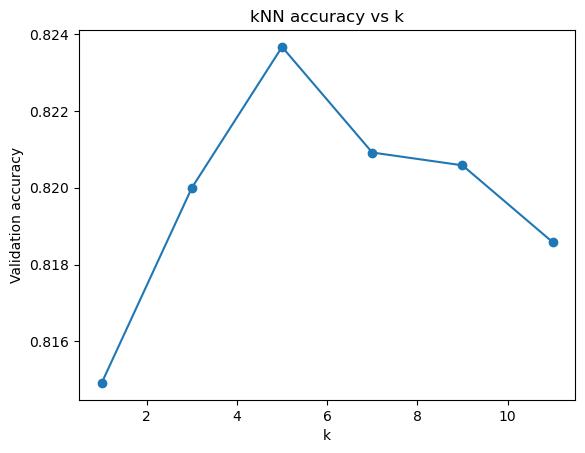

Best k: 5


In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(0)

subset = 12000 # validation set
idx = np.random.choice(len(X_tr), subset, replace=False)

X_knn = X_tr[idx]
y_knn = y_tr[idx]

ks = [1,3,5,7,9,11]
val_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_knn,y_knn)
    pred = model.predict(X_val)
    val_acc.append(accuracy_score(y_val,pred))

plt.plot(ks,val_acc,marker="o")
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("kNN accuracy vs k")
plt.show()

best_k = ks[np.argmax(val_acc)]
print("Best k:",best_k)

In [51]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_knn,y_knn)

knn_test_pred = knn.predict(X_test)

print("kNN test accuracy:", accuracy_score(y_test,knn_test_pred))

kNN test accuracy: 0.8183


In [52]:
## CLASSIFIER 2: Logisitic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, solver="lbfgs")

logreg.fit(X_tr,y_tr)

val_pred = logreg.predict(X_val)
print("LogReg val accuracy:", accuracy_score(y_val,val_pred))

test_pred = logreg.predict(X_test)
print("LogReg test accuracy:", accuracy_score(y_test,test_pred))

LogReg val accuracy: 0.8519166666666667
LogReg test accuracy: 0.8404


In [54]:
## CLASSIFIER 3: Neural Network

/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


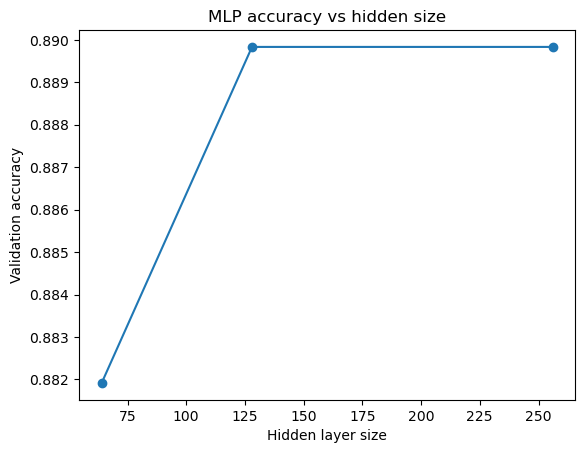

Best hidden size: 128


In [55]:
from sklearn.neural_network import MLPClassifier

hidden_sizes = [64,128,256]
val_acc = []

for h in hidden_sizes:

    mlp = MLPClassifier(
        hidden_layer_sizes=(h,),
        activation="relu",
        solver="adam",
        max_iter=15,
        random_state=0
    )

    mlp.fit(X_tr,y_tr)

    pred = mlp.predict(X_val)

    val_acc.append(accuracy_score(y_val,pred))

plt.plot(hidden_sizes,val_acc,marker="o")
plt.xlabel("Hidden layer size")
plt.ylabel("Validation accuracy")
plt.title("MLP accuracy vs hidden size")
plt.show()

best_h = hidden_sizes[np.argmax(val_acc)]

print("Best hidden size:",best_h)

In [56]:
mlp = MLPClassifier(
    hidden_layer_sizes=(best_h,),
    activation="relu",
    solver="adam",
    max_iter=20,
    random_state=0
)

mlp.fit(X_tr,y_tr)

mlp_test_pred = mlp.predict(X_test)

print("MLP test accuracy:", accuracy_score(y_test,mlp_test_pred))

MLP test accuracy: 0.8814


/opt/miniconda3/envs/cs178/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [57]:
## CLASSIFIER 4: Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

num_trees = [10, 50, 100]
rf_val_acc = []

for n in num_trees:
    rf = RandomForestClassifier(n_estimators=n, max_depth=15, random_state=0)
    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_val)
    rf_val_acc.append(accuracy_score(y_val, pred))
    print(f"Trees: {n}, Val Accuracy: {rf_val_acc[-1]}")

best_n = num_trees[np.argmax(rf_val_acc)]
print("Best number of trees:", best_n)

rf_final = RandomForestClassifier(n_estimators=best_n, max_depth=15, random_state=0)
rf_final.fit(X_tr, y_tr)
rf_test_pred = rf_final.predict(X_test)
print("Random Forest test accuracy:", accuracy_score(y_test, rf_test_pred))

Trees: 10, Val Accuracy: 0.855
Trees: 50, Val Accuracy: 0.8688333333333333
Trees: 100, Val Accuracy: 0.8708333333333333
Best number of trees: 100
Random Forest test accuracy: 0.8639


In [59]:
## Example of Misclassifed images

## Purpose is to show "mistakes", helps with the insight section. 
# It compares the ML predictions to the true labels

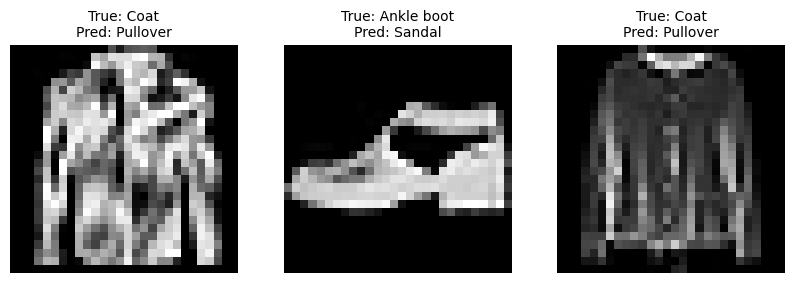

In [60]:
# Find where the MLP predictions don't match the actual test labels
errors = np.where(mlp_test_pred != y_test)[0]

# Set up a plot to see the first 3 mistakes
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

for i, ax in enumerate(axes):
    idx = errors[i] # Get the index of the error
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    
    true_label = class_names[y_test[idx]]
    pred_label = class_names[mlp_test_pred[idx]]
    
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    ax.axis('off')

plt.show()

In [61]:
## Confusion Matrix

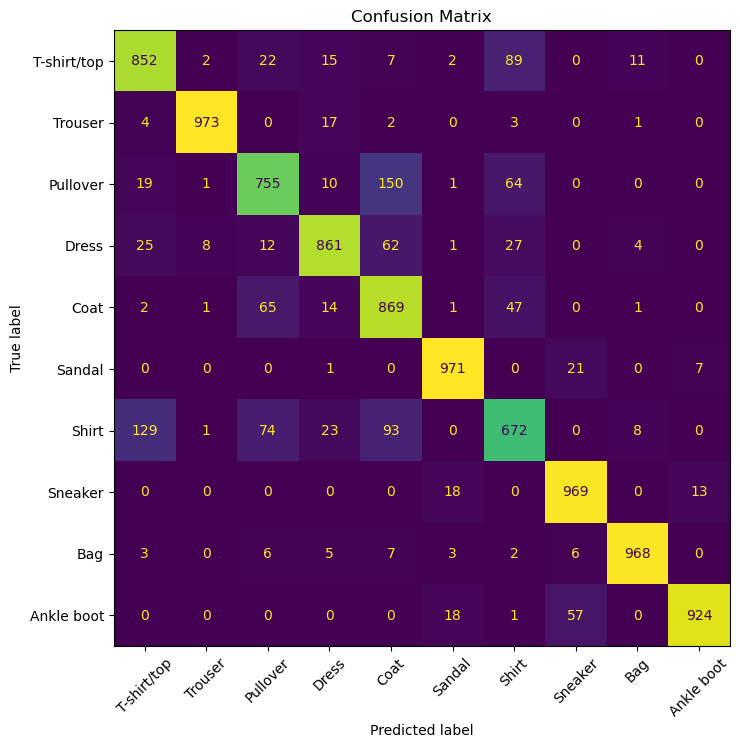

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, mlp_test_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix")
plt.show()